In [1]:
# Unterschiede und Entwicklungen auf dem Immobilienmarkt in Istrien zu untersuchen
# und Standorte mit interessanten Marktmerkmalen für die potenzielle deutsche Immobilienkäufer zu identifizieren.

# Wie haben sich die medianen Preise für Wohnungen und Apartments in Istrien zwischen 2012 und 2025 entwickelt?

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
# Bereinigte Datensätze einlesen 
df_prices = pd.read_csv(
    "data/processed/real_estate_prices_istria_clean.csv"
)
df_transactions = pd.read_csv(
    "data/processed/real_estate_transactions_istria_clean.csv"
)
df_tourism_germany = pd.read_csv(
    "data/processed/tourism_germany_istria_clean.csv"
)
df_tourism_jls = pd.read_csv(
    "data/processed/tourism_istria_jls_clean.csv"
)

In [4]:
# Größe der Datensätze Prüfen 
print("Immobilienpreise:", df_prices.shape)
print("df_transactions:", df_transactions.shape)
print("Tourismus Deutschland:", df_tourism_germany.shape)
print("Tourismus Standorte:", df_tourism_jls.shape)

Immobilienpreise: (41, 18)
df_transactions: (41, 17)
Tourismus Deutschland: (91, 6)
Tourismus Standorte: (468, 5)


In [5]:
# Spalten der Immobilienpreise prüfen 
df_prices.columns

Index(['Šifra', 'Naziv županije', 'Naziv JLS-a', 'Tip JLS-a', '2012.', '2013.',
       '2014.', '2015.', '2016.', '2017.', '2018.', '2019.', '2020.', '2021.',
       '2022.', '2023.', '2024.', '2025.'],
      dtype='str')

In [6]:
# Spalten der Deutschland-Tourismusdaten prüfen 
df_tourism_germany.columns

Index(['Spatial unit', 'Countries', 'Jahr', 'Monat', 'Tourist arrivals',
       'Tourist nights'],
      dtype='str')

In [7]:
# 1. Immobilienmarktanalyse
# Entwicklung der Immobilienpreise in Istrien 2012 - 2025
# Erstmal untersuche ich die medianen Quadratmeterpreise für Wohnungen und Apartments in Städten und Gemeinden in Istrien

#Jahresspalten 
year_columns = [f"{year}." for year in range(2012, 2026)]

#Deskriptive Statistik der Immobilienpreise
df_prices[year_columns].describe()

,2012.,2013.,2014.,2015.,2016.,2017.,2018.,2019.,2020.,2021.,2022.,2023.,2024.,2025.
count,16.000000,15.000000,17.000000,15.000000,18.000000,17.000000,17.000000,18.000000,17.000000,19.000000,22.000000,21.000000,17.000000,15.000000
mean,1219.435748,1140.363011,1163.987572,1105.647983,1066.167005,1116.836396,1223.197075,1215.699434,1317.542592,1427.020255,1480.883859,2083.761905,2343.874375,2589.848307
std,220.343403,228.130685,270.482068,255.809668,231.368204,277.525649,282.084713,342.283491,410.292583,382.080765,463.980444,656.812066,558.114100,431.302250
min,929.908718,768.881375,746.610688,743.540299,680.736390,626.459457,785.774562,469.724224,457.318921,876.828094,843.393761,1229.000000,1445.515015,2039.030029
25%,1037.435948,961.295155,929.743379,938.084664,888.389693,988.352043,1007.531475,994.119860,1014.575696,1181.892426,1055.955933,1889.000000,2033.569946,2302.372559
50%,1185.066127,1128.416959,1137.781661,1071.493762,1072.379702,1137.523631,1185.710631,1200.380974,1237.994955,1305.227233,1469.459108,1982.000000,2166.998779,2456.219971
75%,1333.669390,1222.632708,1391.479754,1281.594791,1226.059625,1263.790684,1409.602607,1472.459473,1620.541654,1672.896862,1791.969019,2228.000000,2731.330078,2802.899902
max,1675.407125,1644.979341,1586.184508,1748.251978,1574.260467,1725.835481,1807.100007,1915.392429,2012.049479,2265.303827,2690.436751,4264.000000,3500.000000,3551.129883


In [8]:
df_prices.head()

,Šifra,Naziv županije,Naziv JLS-a,Tip JLS-a,2012.,2013.,2014.,2015.,2016.,2017.,2018.,2019.,2020.,2021.,2022.,2023.,2024.,2025.
0,51.0,Istarska,BALE - VALLE,Općina,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4264.0,NaN,NaN
1,60.0,Istarska,BARBAN,Općina,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,400.0,Istarska,BRTONIGLA - VERTENEGLIO,Općina,1347.442047,NaN,NaN,1071.493762,1007.848850,1263.790684,1185.710631,1247.057985,NaN,1305.227233,1639.108149,NaN,3265.570068,NaN
3,426.0,Istarska,BUJE - BUIE,Grad,1162.658600,1075.72567,957.842279,1009.878179,876.134871,773.275152,1033.225723,989.219498,998.722961,1139.836690,1313.207293,1229.0,1947.280884,2119.389893
4,434.0,Istarska,BUZET,Grad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,782.457661,NaN,881.521360,895.991784,NaN,NaN,NaN


In [9]:
df_prices[["Naziv JLS-a", "2025."]].dropna()

,Naziv JLS-a,2025.
3,BUJE - BUIE,2119.389893
14,LABIN,2688.030029
16,LIŽNJAN - LISIGNANO,2424.449951
19,MEDULIN,2273.020020
23,PAZIN,2182.264893
25,POREČ - PARENZO,2774.419922
26,PULA - POLA,2456.219971
27,RAŠA,2039.030029
28,ROVINJ - ROVIGNO,3354.735107
29,SVETA NEDELJA,2413.379883


In [10]:
#Korrigierte Immobilienpreise neu einlesen 
df_prices = pd.read_csv(
    "data/processed/real_estate_prices_istria_clean.csv"
)
df_prices.shape

(41, 18)

In [11]:
#Jahresspalten auswählen
year_columns = [f"{year}." for year in range(2012, 2026)]

#Deskriptive Statistik der Immobilienpreise
df_prices[year_columns].describe()

,2012.,2013.,2014.,2015.,2016.,2017.,2018.,2019.,2020.,2021.,2022.,2023.,2024.,2025.
count,16.000000,15.000000,17.000000,15.000000,18.000000,17.000000,17.000000,18.000000,17.000000,19.000000,22.000000,21.000000,17.000000,15.000000
mean,1219.435748,1140.363011,1163.987572,1105.647983,1066.167005,1116.836396,1223.197075,1215.699434,1317.542592,1427.020255,1480.883859,2083.761905,2343.874375,2589.848307
std,220.343403,228.130685,270.482068,255.809668,231.368204,277.525649,282.084713,342.283491,410.292583,382.080765,463.980444,656.812066,558.114100,431.302250
min,929.908718,768.881375,746.610688,743.540299,680.736390,626.459457,785.774562,469.724224,457.318921,876.828094,843.393761,1229.000000,1445.515015,2039.030029
25%,1037.435948,961.295155,929.743379,938.084664,888.389693,988.352043,1007.531475,994.119860,1014.575696,1181.892426,1055.955933,1889.000000,2033.569946,2302.372559
50%,1185.066127,1128.416959,1137.781661,1071.493762,1072.379702,1137.523631,1185.710631,1200.380974,1237.994955,1305.227233,1469.459108,1982.000000,2166.998779,2456.219971
75%,1333.669390,1222.632708,1391.479754,1281.594791,1226.059625,1263.790684,1409.602607,1472.459473,1620.541654,1672.896862,1791.969019,2228.000000,2731.330078,2802.899902
max,1675.407125,1644.979341,1586.184508,1748.251978,1574.260467,1725.835481,1807.100007,1915.392429,2012.049479,2265.303827,2690.436751,4264.000000,3500.000000,3551.129883


In [12]:
# Median der Immobilienpreise pro Jahr berechnen
median_prices = df_prices[year_columns].median()

median_prices

# Von 2012 bis 2016 waren die Preise eher stabil, bzw. leicht rückläufig. Ab 2017/2018 beginnt ein kontinuierlicher Anstieg.
# ab 2022/2023 deutliche steigerung

2012.    1185.066127
2013.    1128.416959
2014.    1137.781661
2015.    1071.493762
2016.    1072.379702
2017.    1137.523631
2018.    1185.710631
2019.    1200.380974
2020.    1237.994955
2021.    1305.227233
2022.    1469.459108
2023.    1982.000000
2024.    2166.998779
2025.    2456.219971
dtype: float64

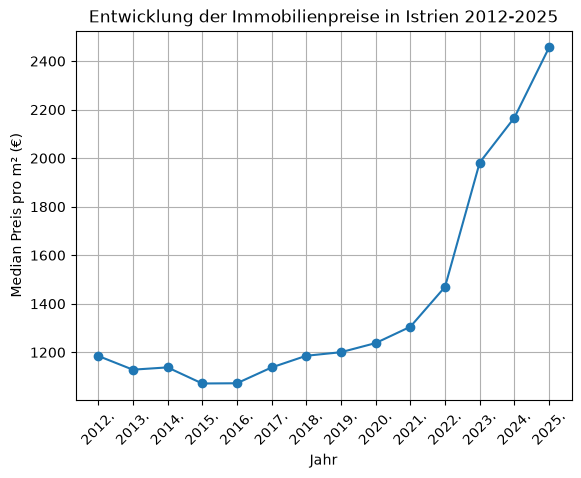

In [13]:
# Entwicklung der medianen Immobilienpreise visualisieren 
plt.Figure(figsize=(10,5))
plt.plot(
    median_prices.index,
    median_prices.values,
    marker="o"
)

plt.title("Entwicklung der Immobilienpreise in Istrien 2012-2025")
plt.xlabel("Jahr")
plt.ylabel("Median Preis pro m² (€)")

plt.xticks(rotation=45)
plt.grid()

plt.show()

# Interpretation 
Die Immobilienpreise in Istrien zeigen zwischen 2012 und 2025 insgesamt eine deutlich steigende Entwicklung.
Zwischen 2012 und 2016 waren die medianen Quadratmeterpreise zunächst relativ stabil bzw. leicht rückläufig. 
Ab 2017 ist ein kontinuierlicher Preisanstieg erkennbar, der sich insbesondere ab 2022 deutlich beschleunigt.
Der Median der verfügbaren Quadratmeterpreise steigt von rund 1.185 €/m² im Jahr 2012 auf rund 2.456 €/m² im Jahr 2015.
Dies entspricht einem Anstieg von etwa 107%.
Bei der Interpretation ist zu berücksichtigen, dass nicht für alle 41 Städte und Gemeinden in jedem Jahr ein veröffentlicher Preis
vorliegt. Der dargestellte Wert entspricht daher dem Median der jeweils verfügbaren JLS-Daten und nicht einem offiziellen Preisindex
für ganz Istrien.

In [14]:
# Preisentwicklung zwischen 2012 und 2025 berechnen
price_change = (
    (median_prices["2025."] - median_prices["2012."])
    / median_prices["2012."]
    * 100
)

print (f"Preisanstieg von 2012 bis 2025: {price_change:.1f} %")

Preisanstieg von 2012 bis 2025: 107.3 %


# Welche istrischen Städte und Gemeinden weisen 2025 die höchsten bzw. niedrigsten veröffentlichten medianen Preise für Wohnungen, Apartments und Familienhäuser pro m² auf?

In [15]:
# Immobilienpreise für 2025 auswählen 
prices_2025 = df_prices[
    ["Naziv JLS-a", "2025."]
].dropna()

# Immobilienpreise absteigend sortieren 
prices_2025 = prices_2025.sort_values(
    by="2025.",
    ascending=False
)

prices_2025

,Naziv JLS-a,2025.
35,UMAG - UMAGO,3551.129883
28,ROVINJ - ROVIGNO,3354.735107
39,VRSAR - ORSERA,2832.219971
33,TAR-VABRIGA - TORRE-ABREGA,2831.379883
25,POREČ - PARENZO,2774.419922
14,LABIN,2688.030029
40,ŽMINJ,2576.330078
26,PULA - POLA,2456.219971
16,LIŽNJAN - LISIGNANO,2424.449951
29,SVETA NEDELJA,2413.379883


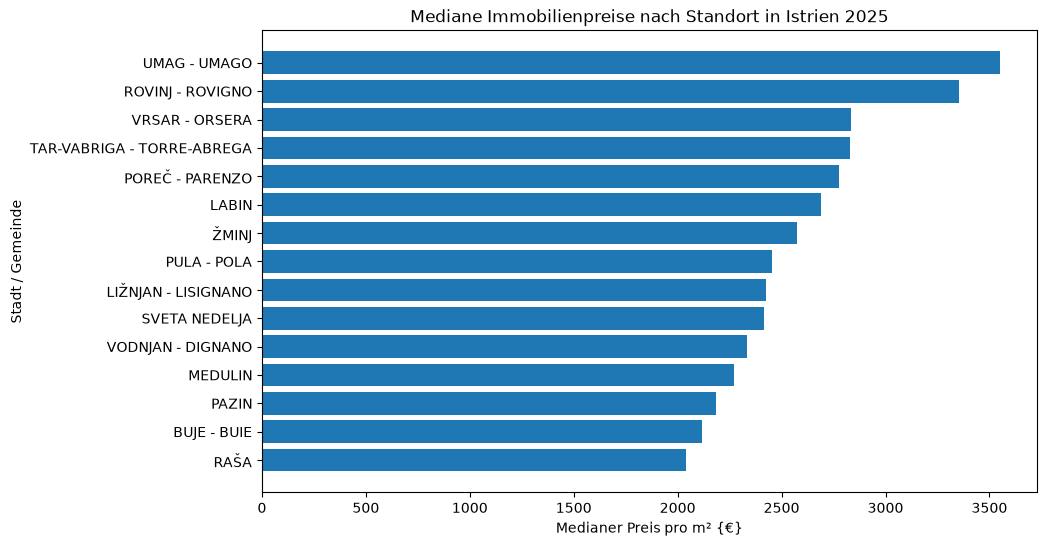

In [16]:
# Immobilienpreise nach Standort für 2025 visualisieren 
plt.figure(figsize=(10, 6))

plt.barh(
    prices_2025["Naziv JLS-a"],
    prices_2025["2025."]
)

plt.title("Mediane Immobilienpreise nach Standort in Istrien 2025")
plt.xlabel("Medianer Preis pro m² {€}")
plt.ylabel("Stadt / Gemeinde")

plt.gca().invert_yaxis()

plt.show()

# Interpretation
Die veröffentlichten medianen Quadratmeterpreise unterscheiden sich 2025 deutlich zwischen den istrischen Städten und Gemeinden.
Den höchsten veröffentlichten Median weist Umag mit rund 3.551 €/m² auf, gefolgt von Rovinj mit rund 3.355 €/m². Auch Vrsar, Tar-Vabriga und Porec liegen auf einem vergleichsweise hohen Preisniveau.Am unteren Ende der betrachteten Standorte liegen Rasa mit rund 2.039 €/m² und Buje mit rund 2.119 €/m². Die Ergebnisse zeigen deutliche regionale Preisunterschiede innerhalb Istriens. Bei der Interpretation ist zu berücksichtigen, dass für 2025 nur Standorte mit veröffentlichten Preiswerten dargestellt werden. Standorte ohne Werte können daher nicht in den Preisvergleich einbezogen werden.

# Wie hat sich die Anzahl der veröffentlichten Immobilientransaktionen zwischen 2012 und 2025 entwickelt und welche Standorte weisen 2025 die höchste Marktaktivität auf?

In [17]:
# Immobilientransaktionsanalyse
# Entwicklung der Immobilientransaktionen in Istrien 2012 - 2025

#Jahresspalten auswählen
year_columns = [f"{year}." for year in range(2012, 2026)]

# Deskriptive Statistik der Immobilientransaktionen
df_transactions[year_columns].describe()

,2012.,2013.,2014.,2015.,2016.,2017.,2018.,2019.,2020.,2021.,2022.,2023.,2024.,2025.
count,15.000000,14.000000,16.000000,14.000000,17.000000,17.000000,17.000000,18.000000,17.000000,19.000000,22.000000,22.000000,17.000000,15.000000
mean,79.733333,91.214286,84.875000,89.285714,98.411765,126.058824,115.000000,100.777778,102.176471,132.052632,118.590909,106.681818,138.823529,93.666667
std,101.344157,115.621517,122.995867,111.443969,140.804412,181.724541,167.935628,117.246626,139.572219,155.683252,164.844128,152.360596,199.109340,108.316775
min,10.000000,11.000000,10.000000,11.000000,10.000000,13.000000,13.000000,15.000000,15.000000,10.000000,10.000000,10.000000,10.000000,13.000000
25%,18.500000,18.250000,14.000000,23.000000,15.000000,23.000000,22.000000,29.000000,25.000000,31.500000,18.000000,20.250000,18.000000,19.000000
50%,35.000000,43.500000,33.500000,36.500000,50.000000,35.000000,55.000000,36.500000,31.000000,45.000000,37.500000,30.000000,76.000000,34.000000
75%,109.000000,135.750000,129.000000,137.500000,105.000000,149.000000,139.000000,130.500000,142.000000,244.000000,158.250000,131.250000,191.000000,129.500000
max,386.000000,438.000000,492.000000,420.000000,572.000000,730.000000,703.000000,434.000000,582.000000,611.000000,667.000000,594.000000,820.000000,388.000000


In [18]:
# Anzahl der Immobilientransaktionen pro Jahr berechnen
transactions_yearly = df_transactions[year_columns].sum()

transactions_yearly

2012.    1196.0
2013.    1277.0
2014.    1358.0
2015.    1250.0
2016.    1673.0
2017.    2143.0
2018.    1955.0
2019.    1814.0
2020.    1737.0
2021.    2509.0
2022.    2609.0
2023.    2347.0
2024.    2360.0
2025.    1405.0
dtype: float64

Die dargestellten Werte entsprechen der Summe der veröffentlichten Immobilientransaktionen der Städte und Gemeinden in Istrien.
In der Originalquelle werden Werte mit einer geringen Anzahl an Transaktionen aus Datenschutzgründen nicht veröffentlicht
Diese Werte wurden bei der Dantebereinigung als fehlende Werte (NaN) behandelt.
Die berechneten Jahressummen stellen daher nicht die vollständige Anzahl aller Immobilientransaktionen in Istrien dar, sondern die
Summe der verfügbaren veröffentlichten Transaktionszahlen.

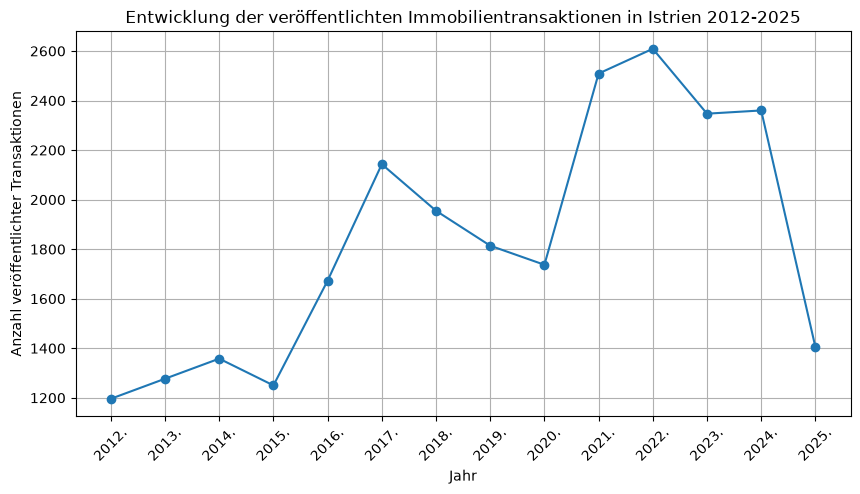

In [19]:
# Entwicklung der Immobilientransaktionen visualisieren 
plt.figure(figsize=(10, 5))

plt.plot(
    transactions_yearly.index,
    transactions_yearly.values,
    marker="o"
)

plt.title("Entwicklung der veröffentlichten Immobilientransaktionen in Istrien 2012-2025")
plt.xlabel("Jahr")
plt.ylabel("Anzahl veröffentlichter Transaktionen")

plt.xticks(rotation=45)
plt.grid()

plt.show()

In [20]:
# Veränderung der veröffentlichten Transaktionen von 2024 zu 2025 berechnen
change_transactions_2025 = (
    (transactions_yearly["2025."] - transactions_yearly["2024."])
    / transactions_yearly["2024."]
)* 100

round(change_transactions_2025, 1)

np.float64(-40.5)

In [21]:
# Standortebene 2025
# In welchen Städten und Gemeinden Istriens wurden 2025 die meisten veröffentlichten Transaktionen für Wohnungen und Apartments erfasst?

# Immobilientransaktionen für 2025 auswählen
transactions_2025 = df_transactions[
    ["Naziv JLS-a", "2025."]
].dropna()

# Transaktionen absteigend 
transactions_2025 = transactions_2025.sort_values(
    by="2025.",
    ascending=False
)

transactions_2025

,Naziv JLS-a,2025.
26,PULA - POLA,388.0
35,UMAG - UMAGO,225.0
25,POREČ - PARENZO,212.0
28,ROVINJ - ROVIGNO,140.0
19,MEDULIN,119.0
21,NOVIGRAD - CITTANOVA,94.0
14,LABIN,54.0
38,VODNJAN - DIGNANO,34.0
33,TAR-VABRIGA - TORRE-ABREGA,34.0
16,LIŽNJAN - LISIGNANO,23.0


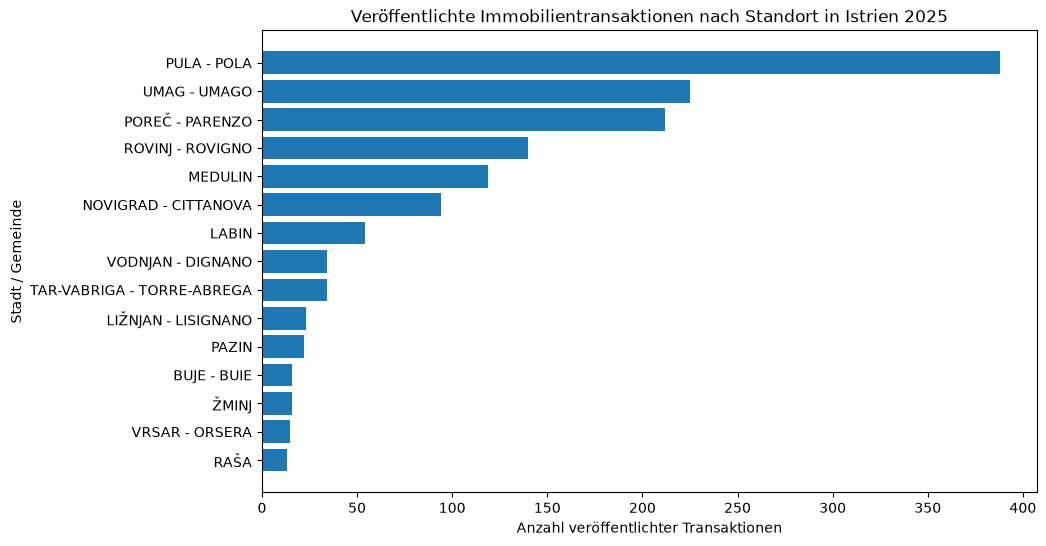

In [22]:
# Immobilientransaktionen nach Standort für 2025 visualisieren 
plt.figure(figsize=(10, 6))

plt.barh(
    transactions_2025["Naziv JLS-a"],
    transactions_2025["2025."]
)

plt.title("Veröffentlichte Immobilientransaktionen nach Standort in Istrien 2025")
plt.xlabel("Anzahl veröffentlichter Transaktionen")
plt.ylabel("Stadt / Gemeinde")

plt.gca().invert_yaxis()

plt.show()

# Interpretation 
Die Zahl der veröffentlichten Immobilientransaktionen in Istrien zeigt zwischen 2012 und 2025 deutliche Schwankungen. Nach einem Anstieg bis 2022 ging die Marktaktivität in den folgenden Jahren zurück. Besonders deutlich ist der Rückgang von 2024 auf 2025.
Auf Standortebene weist Pula 2025 mit 388 veröffentlichten Transaktionen die höchste Marktaktivität auf.
Es folgen Umag mit 255 und Porec mit 212 Transaktionen. Rovinj und Medulin gehören ebenfalls zu den Standorten mit vergleichsweise hoher Marktaktiviät .
Die Ergebnisse zeigen, dass sich die Marktaktivität innerhalb Istriens deutlich zwischen den einzelnen Stödten und Gemeinden unterscheidet. Dabei werden ausschließlich veröffentlichte Transaktionszahlen berücksichtigt.

# Zusammenhang zwsichen Immobilienpreisen und Transaktionen 2025
# Besteht 2025 ein Zusammenhang zwischen den Immobilienpreisen und Marktaktivität?

Für die Analyse werden die medianen Immobilienpreise pro m² und die veröffentlichten Transaktionszahlen auf Standortebene zusammengeführt.Anschließend wir untersucht, ob Standorte mit höheren Immobilienpreisen tendenziell auch eine höhere Marktaktivität aufweisen.

In [23]:
# Immobilienpreise und Transaktionen für 2025 zusammenführen 
market_2025 = pd.merge(
    prices_2025,
    transactions_2025,
    on="Naziv JLS-a",
    suffixes=("_Preis", "_Transaktionen")
)

market_2025

,Naziv JLS-a,2025._Preis,2025._Transaktionen
0,UMAG - UMAGO,3551.129883,225.0
1,ROVINJ - ROVIGNO,3354.735107,140.0
2,VRSAR - ORSERA,2832.219971,15.0
3,TAR-VABRIGA - TORRE-ABREGA,2831.379883,34.0
4,POREČ - PARENZO,2774.419922,212.0
5,LABIN,2688.030029,54.0
6,ŽMINJ,2576.330078,16.0
7,PULA - POLA,2456.219971,388.0
8,LIŽNJAN - LISIGNANO,2424.449951,23.0
9,VODNJAN - DIGNANO,2331.725098,34.0


In [24]:
# Größe der zusammengeführten Datensatzes 
market_2025.shape

(14, 3)

In [25]:
#Fehlende Werte
market_2025.isna().sum()

Naziv JLS-a            0
2025._Preis            0
2025._Transaktionen    0
dtype: int64

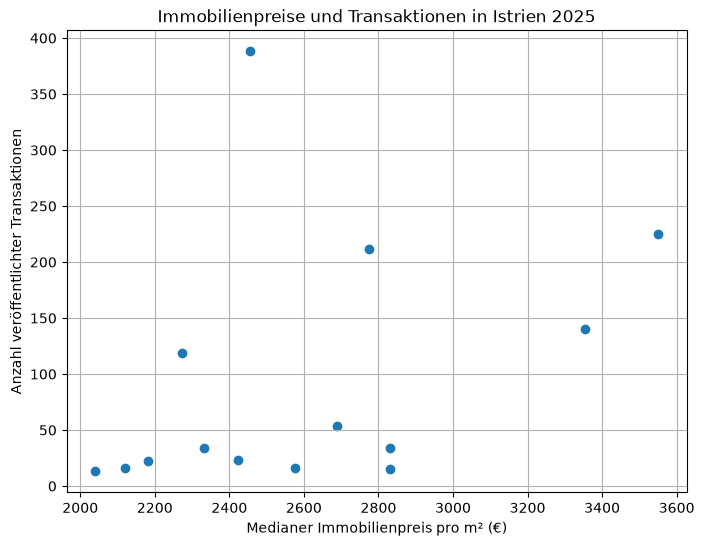

In [26]:
# Zusammenhang zwischen Immobilienpreisen und Transaktionen visualisieren 
plt.figure(figsize=(8, 6))

plt.scatter(
    market_2025["2025._Preis"],
    market_2025["2025._Transaktionen"]
)

plt.title("Immobilienpreise und Transaktionen in Istrien 2025")
plt.xlabel("Medianer Immobilienpreis pro m² (€)")
plt.ylabel("Anzahl veröffentlichter Transaktionen")
plt.grid()

plt.show()

In [27]:
# Korrelation zwischen Immobilienpreisen und Transaktionen 
correlation = market_2025[
    ["2025._Preis", "2025._Transaktionen"]
].corr()

correlation

,2025._Preis,2025._Transaktionen
2025._Preis,1.000000,0.364897
2025._Transaktionen,0.364897,1.000000


# Korrelation
Zwischen dem medianen Immobilienpreis pro m² und der Anzahl der veröffentlichten Immobilientransaktionen besteht 2025 ein schwach bis moderat positiver Zusammenhang (r = 0,36).
Standorte mit höheren Immobilienpreisen weisen damit tendenziell auch eine höhere Marktaktivität auf.
Der Zusammenhang ist jedoch nicht stark ausgeprägt. Die Analyse basiert auf 14 Standorten, für die sowohl Preis- als auch Transaktionsdaten veröffentlicht wurden.

# Lineare Regression 
Ergänzend zur Korrelationsanalyse wird eine einfache lineare Regression durchgeführt.
Dabei wird untersucht, in welchem Umfang der Immobilienpreise pro m² die Unterschiede in der Anzahl der veröffentlichten Transaktionen zwischen den Standorten statistisch erklären kann.

In [28]:
# Unabhänige Variable x definieren 
x = market_2025[["2025._Preis"]] # x = Immobilienpreis pro m²

# Abhängige Variable y definieren
y = market_2025["2025._Transaktionen"] # y = Anzahl der Transaktionen

In [29]:
print(x.head())
print(y.head())

   2025._Preis
0  3551.129883
1  3354.735107
2  2832.219971
3  2831.379883
4  2774.419922
0    225.0
1    140.0
2     15.0
3     34.0
4    212.0
Name: 2025._Transaktionen, dtype: float64


In [30]:
# import statsmodels.api as sm 

In [31]:
# Werte für die lineare Regression vorbereiten
x_values = x.to_numpy()
y_values = y.to_numpy()

x_values[:5]

array([[3551.12988281],
       [3354.73510742],
       [2832.2199707 ],
       [2831.37988281],
       [2774.41992188]])

In [32]:
import numpy as np
# Lineare Regression berechnen
slope, intercept = np.polyfit(
    x_values.flatten(),
    y_values,
    1
)

print("Steigung:", slope)
print("Achsenabschnitt:", intercept)

Steigung: 0.09223263682414361
Achsenabschnitt: -146.38826322076363


In [33]:
# Vorhergesagte Werte berechnen
y_pred = slope * x_values.flatten() + intercept

# Bestimmtheitsmaß R² berechnen
ss_res = np.sum((y_values - y_pred) ** 2)
ss_tot = np.sum((y_values - np.mean(y_values)) ** 2)

r_squared = 1 - (ss_res / ss_tot)

print("R²:", r_squared)

R²: 0.13315012529817194


In [34]:
from scipy import stats

# p-Wert für die Steigerung berechnen
n = len(x_values)

standard_error = np.sqrt(
    ss_res / (n - 2)
    / np.sum((x_values.flatten() - np.mean(x_values)) ** 2)
)

t_value = slope / standard_error
p_value = 2 * (1 - stats.t.cdf(abs(t_value), df=n -2))

print("p-Wert:", p_value)

p-Wert: 0.1995557417550673


### Interpretation der linearen Regression 

Die lineare Regression untersucht den Zusammenhng zwischen dem medianen Immobilienpreis pro m² und der Anzahl der veröffentlichten Immobilientransaktionen der istrischen Standorte im Jahr 2025.

Das Bestimmtheitsmaß R² beträgt 0,133. Damit können rund 13,3% der Unterschiede in den veröffentlichten Transaktionszahlen durch das 
Preisniveau im einfachen linearen Modell erklärt werden.

Der Regressionskoeffizient des Immobilienpreises ist positiv (0,0922) und der Zusammenhang ist jedoch mit einem p-Wert von 0,200 nicht statistisch signigikant (p > 0,05)

Auf Basis der 14 verfügbaren Standorten kann daher kein statistisch signifikanter linearer Zusammenhang zwischen dem Immobilienpreis pro m² und der Anzahl der veröffentlichten Transaktionen für 2025 nahgewisen werden.

Die Ergebnisse sollten aufgrund der kleinen Stichprobe und der teilweise unterdrückten Transaktionswerte vorsichtig interpretiert werden.

In [35]:
import pandas as pd

In [36]:
# Bereinigte Familienhaus-Daten einlesen
df_house_prices = pd.read_csv(
    "data/processed/real_estate_house_prices_clean.csv"
)

df_house_transactions = pd.read_csv(
    "data/processed/real_estate_house_transactions_istria_clean.csv"
)

In [37]:
df_house_prices.head()

,Šifra,Naziv županije,Naziv JLS-a,Tip JLS-a,2012.,2013.,2014.,2015.,2016.,2017.,2018.,2019.,2020.,2021.,2022.,2023.,2024.,2025.
0,51.0,Istarska,BALE - VALLE,Općina,NaN,NaN,NaN,NaN,NaN,466.002473,580.532161,828.009801,370.023937,852.731767,639.458491,1578.0,1263.0,1498.0
1,60.0,Istarska,BARBAN,Općina,NaN,NaN,NaN,NaN,NaN,NaN,105.034844,247.215071,NaN,195.908320,240.756517,NaN,NaN,NaN
2,400.0,Istarska,BRTONIGLA - VERTENEGLIO,Općina,NaN,NaN,NaN,NaN,NaN,399.274793,410.414695,292.134893,285.713803,528.087242,472.385685,782.0,493.0,860.0
3,426.0,Istarska,BUJE - BUIE,Grad,433.350883,417.489927,513.189098,409.578636,786.173316,207.635284,229.390952,277.423270,319.340162,374.023329,319.603165,641.0,677.0,575.0
4,434.0,Istarska,BUZET,Grad,204.529837,145.459565,NaN,NaN,NaN,85.496844,109.225502,71.497834,101.134593,171.957536,72.562210,223.0,310.0,136.0


In [38]:
df_house_transactions.head()

,Šifra,Naziv županije,Naziv JLS-a,2012.,2013.,2014.,2015.,2016.,2017.,2018.,2019.,2020.,2021.,2022.,2023.,2024.,2025.
0,51.0,Istarska,BALE - VALLE,NaN,NaN,NaN,NaN,NaN,12.0,13.0,17.0,13.0,23.0,49.0,15.0,15.0,11.0
1,60.0,Istarska,BARBAN,NaN,NaN,NaN,NaN,NaN,NaN,17.0,10.0,NaN,12.0,13.0,NaN,NaN,NaN
2,400.0,Istarska,BRTONIGLA - VERTENEGLIO,NaN,NaN,NaN,NaN,NaN,NaN,23.0,24.0,18.0,16.0,46.0,21.0,14.0,17.0
3,426.0,Istarska,BUJE - BUIE,14.0,11.0,17.0,10.0,13.0,NaN,36.0,43.0,36.0,71.0,89.0,40.0,28.0,46.0
4,434.0,Istarska,BUZET,13.0,12.0,NaN,NaN,NaN,NaN,17.0,36.0,24.0,45.0,47.0,46.0,20.0,43.0


Entwicklung der Familienhauspreise 2012-2025

In [39]:
# Jahresplan für die Analyse definieren
year_columns = [f"{year}." for year in range(2012, 2026)]

In [40]:
#Median der Familienhauspreis pro Jahr berechnen
house_price_median = df_house_prices[year_columns].median()

house_price_median

2012.     787.175023
2013.     962.185755
2014.    1054.295575
2015.    1177.862348
2016.     977.288577
2017.     395.339207
2018.     237.474194
2019.     236.897077
2020.     278.211565
2021.     374.023329
2022.     384.711674
2023.     525.000000
2024.     504.000000
2025.     583.000000
dtype: float64

In [41]:
# Anzahl der verfügbaren Familienpreise pro Jahr prüfen
house_price_count = df_house_prices[year_columns].count()

house_price_count

2012.     6
2013.     7
2014.     7
2015.    10
2016.    13
2017.    21
2018.    27
2019.    28
2020.    26
2021.    33
2022.    34
2023.    26
2024.    24
2025.    24
dtype: int64

In [42]:
# Standorte mit vollständigen Preiswerten von 2012 bis 2025 prüfen
complete_house_prices = df_house_prices.dropna(
    subset=year_columns
)

complete_house_prices[
    ["Naziv JLS-a"] + year_columns
]

,Naziv JLS-a,2012.,2013.,2014.,2015.,2016.,2017.,2018.,2019.,2020.,2021.,2022.,2023.,2024.,2025.
3,BUJE - BUIE,433.350883,417.489927,513.189098,409.578636,786.173316,207.635284,229.390952,277.423270,319.340162,374.023329,319.603165,641.0,677.0,575.0
26,PULA - POLA,1036.516097,990.288832,671.685530,842.408820,650.101077,280.134325,218.207543,432.930594,298.784829,277.485289,549.585902,615.0,455.0,610.0


In [43]:
# Anzahl der Standorte mit vollständiger Zeitreihe
complete_house_prices.shape[0]

2

# Interpretation 
Die veröffentlichten Medianpreise für Familienhäuser unterscheiden sich im Zeitraum 2012-2025 deutlich zwischen den einzelnen Jahre. Eine direkte Interpretation als kontinuierliche Preisentwicklung ist jedoch nur eingeschränkt möglich. 
Für Familienhäuser liegen nicht für alle istrischen Städte und Gemeinden in jedem Jahr veröffentlichte Preisdaten vor. Lediglich zwei Standorte verfügen über eine vollständige Zeitreihe von 2012 bis 2025. Veränderungen des jährlichen Medians können daher teilweise auch durch eine unterschiedliche Zusammensetzung der verfügbaren Standorte beeinflusst werden. Für die weitere Standortanalyse wird deshalb insbesondere das Jahr 2025 betrachtet.

In [44]:
# Familienpreise nach Standort für 2025
df_house_prices_2025 = (
    df_house_prices[
        ["Naziv JLS-a", "2025."]
    ]
    .dropna()
    .sort_values(
        by="2025.",
        ascending=False
    )
)

df_house_prices_2025

,Naziv JLS-a,2025.
39,VRSAR - ORSERA,1772.0
0,BALE - VALLE,1498.0
28,ROVINJ - ROVIGNO,1278.0
21,NOVIGRAD - CITTANOVA,966.0
2,BRTONIGLA - VERTENEGLIO,860.0
25,POREČ - PARENZO,749.0
33,TAR-VABRIGA - TORRE-ABREGA,688.0
19,MEDULIN,656.0
36,VIŠNJAN - VISIGNANO,635.0
26,PULA - POLA,610.0


In [45]:
# Familienhaus-Transaktionen nach Standort für 2025
df_house_transactions_2025 = (
df_house_transactions[
    ["Naziv JLS-a", "2025."]
]
.dropna()
.sort_values(
    by="2025.",
    ascending=False
    )
)

df_house_transactions_2025

,Naziv JLS-a,2025.
35,UMAG - UMAGO,69.0
25,POREČ - PARENZO,51.0
28,ROVINJ - ROVIGNO,50.0
3,BUJE - BUIE,46.0
4,BUZET,43.0
21,NOVIGRAD - CITTANOVA,33.0
14,LABIN,33.0
29,SVETA NEDELJA,24.0
18,MARČANA,20.0
34,TINJAN,19.0


In [46]:
# Familienhauspreise und Transaktionen für 2025 zusammenführen 
df_hous_market_2025 = pd.merge(
    df_house_prices_2025,
    df_house_transactions_2025,
    on="Naziv JLS-a",
    suffixes=("_Preis", "_Transaktionen")
)

df_hous_market_2025

,Naziv JLS-a,2025._Preis,2025._Transaktionen
0,VRSAR - ORSERA,1772.0,12.0
1,BALE - VALLE,1498.0,11.0
2,ROVINJ - ROVIGNO,1278.0,50.0
3,NOVIGRAD - CITTANOVA,966.0,33.0
4,BRTONIGLA - VERTENEGLIO,860.0,17.0
5,POREČ - PARENZO,749.0,51.0
6,TAR-VABRIGA - TORRE-ABREGA,688.0,13.0
7,MEDULIN,656.0,12.0
8,VIŠNJAN - VISIGNANO,635.0,11.0
9,PULA - POLA,610.0,13.0


In [47]:
df_hous_market_2025.shape

(24, 3)

In [48]:
# Zusammenhang zwischen Familienhauspreisen und Transaktionen 2025
house_correlation = df_hous_market_2025[
    ["2025._Preis", "2025._Transaktionen"]
].corr()

house_correlation

,2025._Preis,2025._Transaktionen
2025._Preis,1.000000,0.052092
2025._Transaktionen,0.052092,1.000000


# Interpretation

Die Korrelation zwischen den medianen Familienhauspreisen und den veröffetlichten Transaktionszahlen im Jahr 2025 beträgt rund 0,05.
Damit besteht nahezu kein linearer Zusammenhang zwischen dem Preisniveau und der Marktaktivität der untersuchten Standorte.
Ein höherer Medianpreis für Familienhäuser geht somit 2025 nicht automatisch mit einer höheren Anzahl veröffentlichter Transaktionen einher. Die Analyse basiert auf 24 istrischen Städten und Gemeinden für die sowhol Preis- als auch Transaktionsdaten veröffentlicht wurden.

# Wie hat sich die touristische Nachfrage aus Deutschland in Istrien zwischen 2019 und 2025 entwickelt?

In [49]:
# Bereinigte Tourismusdaten für deutsche Gäste einlesen
df_tourism_germany = pd.read_csv(
    "data/processed/tourism_germany_istria_clean.csv"
)

df_tourism_germany.head()

,Spatial unit,Countries,Jahr,Monat,Tourist arrivals,Tourist nights
0,County of Istria,Germany,2019,01,478,5512
1,County of Istria,Germany,2019,02,1445,4951
2,County of Istria,Germany,2019,03,10138,40996
3,County of Istria,Germany,2019,04,44181,214843
4,County of Istria,Germany,2019,05,65858,396073


In [50]:
df_tourism_germany.shape

(91, 6)

In [51]:
df_tourism_germany.info()

<class 'pandas.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Spatial unit      91 non-null     str  
 1   Countries         91 non-null     str  
 2   Jahr              91 non-null     int64
 3   Monat             91 non-null     str  
 4   Tourist arrivals  91 non-null     int64
 5   Tourist nights    91 non-null     int64
dtypes: int64(3), str(3)
memory usage: 4.4 KB


In [52]:
# Jahresgesamtwerte für deutsche Gäste 
df_germany_yearly = df_tourism_germany.loc[
    df_tourism_germany["Monat"] == "Gesamt"
]

df_germany_yearly

,Spatial unit,Countries,Jahr,Monat,Tourist arrivals,Tourist nights
12,County of Istria,Germany,2019,Gesamt,1051643,8580194
25,County of Istria,Germany,2020,Gesamt,594375,5116483
38,County of Istria,Germany,2021,Gesamt,1145072,9332509
51,County of Istria,Germany,2022,Gesamt,1309379,10871010
64,County of Istria,Germany,2023,Gesamt,1285731,10459665
77,County of Istria,Germany,2024,Gesamt,1231169,9916343
90,County of Istria,Germany,2025,Gesamt,1233549,9962630


In [53]:
# Werte für 2019 und 2025 prüfen
arrivals_2019 = df_germany_yearly.loc[
    df_germany_yearly["Jahr"] == 2019,
    "Tourist arrivals"
].iloc[0]

arrivals_2025 = df_germany_yearly.loc[
    df_germany_yearly["Jahr"] == 2025,
    "Tourist arrivals"
].iloc[0]

print(arrivals_2019, type(arrivals_2019))
print(arrivals_2025, type(arrivals_2025))

1051643 <class 'numpy.int64'>
1233549 <class 'numpy.int64'>


In [54]:
#Prozentuale Veränderung der deutschen Gästeankünften von 2019 bis 2025
change_arrivals = (
    (arrivals_2025 - arrivals_2019)
    / arrivals_2019
    *100
)

change_arrivals

np.float64(17.297314773169223)

In [55]:
# Übenachtungen 2019 und 2025 auswählen 
nights_2019 = df_germany_yearly.loc[
    df_germany_yearly["Jahr"] == 2019,
    "Tourist nights"
].iloc[0]

nights_2025 = df_germany_yearly.loc[
    df_germany_yearly["Jahr"] == 2025,
    "Tourist nights"
].iloc[0]

#Prozentuale Veränderung der Übernachtungen 
change_nights = (
    (nights_2025 - nights_2019)
    / nights_2019
    *100
)

change_nights

np.float64(16.11194338962499)

In [56]:
# Entwicklung der deutschen Gäste von 2019 bis 2025
germany_development = df_germany_yearly[
    ["Jahr", "Tourist arrivals", "Tourist nights"]
].reset_index(drop=True)

germany_development

,Jahr,Tourist arrivals,Tourist nights
0,2019,1051643,8580194
1,2020,594375,5116483
2,2021,1145072,9332509
3,2022,1309379,10871010
4,2023,1285731,10459665
5,2024,1231169,9916343
6,2025,1233549,9962630


In [57]:
# Durschnittliche Aufenthalstdauer 
germany_development["Avg stay"] = (
    germany_development["Tourist nights"]
    / germany_development["Tourist arrivals"]
)

germany_development

,Jahr,Tourist arrivals,Tourist nights,Avg stay
0,2019,1051643,8580194,8.158847
1,2020,594375,5116483,8.608173
2,2021,1145072,9332509,8.150150
3,2022,1309379,10871010,8.302417
4,2023,1285731,10459665,8.135189
5,2024,1231169,9916343,8.054413
6,2025,1233549,9962630,8.076396


# Interpreation 
Die touristische Nachfrage aus Deutschland entwickelelte sich zwischen 2019 und 2025 insgesamt positiv.
Die Zahl der Gästeankünfte stieg von rund 1,05 Mio. im Jahr 2019 auf rund 1,23 Mio. im Jahr 202, was einem Anstieg von etwa 17,3 % entspricht. Die Zahl der Übernachtungen erhöhte sich im gleichen Zeitraum von rund 8,58 Mio. auf rund 9,96 Mio. und damit um etwa 16,11%
Nach dem deutlichen Rückgang im Jahr 2020 erholte sich die Nachfrage stark und erreichte 2022 einen zwischenzeitlichen Höchstand. 
Die durchschnittliche Aufenhaltsdauer bleibt über den betrachteten Zeitraum mit rund 8 Nächten relativ stabil.
Die Ergebnisse unterstreichen die Bedeutung Deutschlands als relevanten touristischen Herkunftsmarkt für Istrien. Sie erlauben jedoch keine Aussage darüber, ob deutsche Touristen gleichzeitig potenzielle Immobilienkäufer sind.

# Welche istrischen Standorte verbinden Immobilienmarktaktivität mit einer hohen touristischen Nachfrage?

In [58]:
# Tourismusdaten nach Städten und Gemeinden laden 
df_tourism_jls = pd.read_csv(
    "data/processed/tourism_istria_jls_clean.csv"
)

df_tourism_jls.head()

,Spatial unit,Jahr,Monat,Tourist arrivals,Tourist nights
0,Medulin,2020,01,1400.0,6425.0
1,Medulin,2020,02,4040.0,14549.0
2,Medulin,2020,03,1745.0,5207.0
3,Medulin,2020,04,2.0,46.0
4,Medulin,2020,05,1800.0,4779.0


In [59]:
df_tourism_jls.shape

(468, 5)

In [60]:
df_tourism_jls.info()

<class 'pandas.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Spatial unit      468 non-null    str    
 1   Jahr              468 non-null    int64  
 2   Monat             468 non-null    str    
 3   Tourist arrivals  445 non-null    float64
 4   Tourist nights    445 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 18.4 KB


In [61]:
#Enthaltene Städte und Gemeinden prüfen 
df_tourism_jls["Spatial unit"].unique()

<StringArray>
[         'Medulin',         'Novigrad',  'Pore  - Parenzo',
      'Pula - Pola', 'Rovinj - Rovigno',      'Umag -Umago']
Length: 6, dtype: str

In [62]:
#Anzahl der enthaltenen Städte und Gemeinden
df_tourism_jls["Spatial unit"].nunique()

6

In [63]:
#Tourismusdaten für 2025 
df_tourism_jls_2025 = df_tourism_jls.loc[
    df_tourism_jls["Jahr"] == 2025
]

df_tourism_jls_2025

,Spatial unit,Jahr,Monat,Tourist arrivals,Tourist nights
65,Medulin,2025,01,2824.0,10918.0
66,Medulin,2025,02,4777.0,14367.0
67,Medulin,2025,03,4005.0,12991.0
68,Medulin,2025,04,19047.0,65414.0
69,Medulin,2025,05,31103.0,119761.0
...,...,...,...,...,...
463,Umag -Umago,2025,09,62236.0,331901.0
464,Umag -Umago,2025,10,18614.0,60406.0
465,Umag -Umago,2025,11,3054.0,8517.0
466,Umag -Umago,2025,12,3367.0,8514.0


In [64]:
# Jahresgesamtwerte der Toruismusdaten für 2025
df_tourism_jls_2025 = df_tourism_jls.loc[
    (df_tourism_jls["Jahr"] == 2025)
    & (df_tourism_jls["Monat"] == "Gesamt")
]

df_tourism_jls_2025

,Spatial unit,Jahr,Monat,Tourist arrivals,Tourist nights
77,Medulin,2025,Gesamt,446639.0,2627303.0
155,Novigrad,2025,Gesamt,8018.0,53348.0
233,Pore - Parenzo,2025,Gesamt,643903.0,3288169.0
311,Pula - Pola,2025,Gesamt,462949.0,2014954.0
389,Rovinj - Rovigno,2025,Gesamt,759719.0,4226580.0
467,Umag -Umago,2025,Gesamt,530566.0,2613699.0


In [65]:
# Standortnamen aus Tourismus und Immobiliendaten vergleichen 
print("Tourismus:")
print(df_tourism_jls_2025["Spatial unit"].tolist())

print("\nImmobilien:")
print(df_hous_market_2025["Naziv JLS-a"].tolist())

Tourismus:
['Medulin', 'Novigrad', 'Pore  - Parenzo', 'Pula - Pola', 'Rovinj - Rovigno', 'Umag -Umago']

Immobilien:
['VRSAR - ORSERA', 'BALE - VALLE', 'ROVINJ - ROVIGNO', 'NOVIGRAD - CITTANOVA', 'BRTONIGLA - VERTENEGLIO', 'POREČ - PARENZO', 'TAR-VABRIGA - TORRE-ABREGA', 'MEDULIN', 'VIŠNJAN - VISIGNANO', 'PULA - POLA', 'SVETVINČENAT', 'MARČANA', 'BUJE - BUIE', 'UMAG - UMAGO', 'KANFANAR', 'LABIN', 'TINJAN', 'OPRTALJ - PORTOLE', 'KRŠAN', 'PAZIN', 'SVETA NEDELJA', 'RAŠA', 'BUZET', 'GROŽNJAN - GRISIGNANA']


In [66]:
# Standortnamen für die Zusammenführung vereinheitlichen
df_tourism_jls_2025 = df_tourism_jls_2025.copy()

df_tourism_jls_2025["Standort"] = (
    df_tourism_jls_2025["Spatial unit"]
    .replace({
        "Medulin": "MEDULIN",
        "Novigrad": "NOVIGRAD - CITTANOVA",
        "Pore - Parenzo": "POREČ - PARENZO",
        "Pula - Pola": "PULA - POLA",
        "Rovinj - Rovigno": "ROVINJ - ROVINGO",
        "Umag -Umago": "UMAG - UMAGO"
    })
)

In [67]:
df_tourism_jls_2025[
    ["Spatial unit", "Standort"]
]

,Spatial unit,Standort
77,Medulin,MEDULIN
155,Novigrad,NOVIGRAD - CITTANOVA
233,Pore - Parenzo,Pore - Parenzo
311,Pula - Pola,PULA - POLA
389,Rovinj - Rovigno,ROVINJ - ROVINGO
467,Umag -Umago,UMAG - UMAGO


In [68]:
df_tourism_jls_2025["Standort"] = (
    df_tourism_jls_2025["Standort"]
    .replace({
        "Pore - Parenzo": "POREČ - PARENZO"
            })
)

In [69]:
df_tourism_jls_2025[
    ["Spatial unit", "Standort"]
]

,Spatial unit,Standort
77,Medulin,MEDULIN
155,Novigrad,NOVIGRAD - CITTANOVA
233,Pore - Parenzo,Pore - Parenzo
311,Pula - Pola,PULA - POLA
389,Rovinj - Rovigno,ROVINJ - ROVINGO
467,Umag -Umago,UMAG - UMAGO


In [70]:
repr(df_tourism_jls_2025.loc[233, "Spatial unit"])

"'Pore  - Parenzo'"

In [71]:
df_tourism_jls_2025["Standort"] = (
    df_tourism_jls_2025["Standort"]
    .replace({
        "Pore - Parenzo": "POREČ - PARENZO"
            })
)

In [72]:
df_tourism_jls_2025[
    ["Spatial unit", "Standort"]
]

,Spatial unit,Standort
77,Medulin,MEDULIN
155,Novigrad,NOVIGRAD - CITTANOVA
233,Pore - Parenzo,Pore - Parenzo
311,Pula - Pola,PULA - POLA
389,Rovinj - Rovigno,ROVINJ - ROVINGO
467,Umag -Umago,UMAG - UMAGO


In [73]:
df_tourism_jls_2025.loc[233, "Standort"] = "POREČ - PARENZO"

In [74]:
df_tourism_jls_2025[
    ["Spatial unit", "Standort"]
]

,Spatial unit,Standort
77,Medulin,MEDULIN
155,Novigrad,NOVIGRAD - CITTANOVA
233,Pore - Parenzo,POREČ - PARENZO
311,Pula - Pola,PULA - POLA
389,Rovinj - Rovigno,ROVINJ - ROVINGO
467,Umag -Umago,UMAG - UMAGO


In [75]:
df_tourism_jls_2025.loc[77, "Standort"] = "MEDULIN"
df_tourism_jls_2025.loc[155, "Standort"] = "NOVIGRAD - CITTANOVA"
df_tourism_jls_2025.loc[311, "Standort"] = "PULA - POLA"
df_tourism_jls_2025.loc[389, "Standort"] = "ROVINJ - ROVINGO"
df_tourism_jls_2025.loc[467, "Standort"] = "UMAG - UMAGO"

In [76]:
df_tourism_jls_2025[
    ["Spatial unit", "Standort"]
]

,Spatial unit,Standort
77,Medulin,MEDULIN
155,Novigrad,NOVIGRAD - CITTANOVA
233,Pore - Parenzo,POREČ - PARENZO
311,Pula - Pola,PULA - POLA
389,Rovinj - Rovigno,ROVINJ - ROVINGO
467,Umag -Umago,UMAG - UMAGO


In [77]:
# Familienhausmarkt und Tourismusdaten für 2025 zusammenführen
df_house_tourism_2025 = df_hous_market_2025.merge(
    df_tourism_jls_2025[
        ["Standort", "Tourist arrivals", "Tourist nights"]
    ],
left_on="Naziv JLS-a",
right_on="Standort",
how="inner"
)

df_house_tourism_2025

,Naziv JLS-a,2025._Preis,2025._Transaktionen,Standort,Tourist arrivals,Tourist nights
0,NOVIGRAD - CITTANOVA,966.0,33.0,NOVIGRAD - CITTANOVA,8018.0,53348.0
1,POREČ - PARENZO,749.0,51.0,POREČ - PARENZO,643903.0,3288169.0
2,MEDULIN,656.0,12.0,MEDULIN,446639.0,2627303.0
3,PULA - POLA,610.0,13.0,PULA - POLA,462949.0,2014954.0
4,UMAG - UMAGO,562.0,69.0,UMAG - UMAGO,530566.0,2613699.0


In [78]:
print(
    df_hous_market_2025.loc[
        df_hous_market_2025["Naziv JLS-a"].str.contains("ROVINJ"),
        "Naziv JLS-a"
    ]
)

print(
    df_tourism_jls_2025.loc[
        df_tourism_jls_2025["Spatial unit"].str.contains("Rovinj"),
        ["Spatial unit", "Standort"]
    ]
)

2    ROVINJ - ROVIGNO
Name: Naziv JLS-a, dtype: str
         Spatial unit          Standort
389  Rovinj - Rovigno  ROVINJ - ROVINGO


In [79]:
df_tourism_jls_2025["Standort"] = (
    df_tourism_jls_2025["Standort"]
    .replace({
        "ROVINJ - ROVINGO": "ROVINJ - ROVIGNO"
    })
)

In [80]:
df_tourism_jls_2025[
    ["Spatial unit", "Standort"]
]

,Spatial unit,Standort
77,Medulin,MEDULIN
155,Novigrad,NOVIGRAD - CITTANOVA
233,Pore - Parenzo,POREČ - PARENZO
311,Pula - Pola,PULA - POLA
389,Rovinj - Rovigno,ROVINJ - ROVIGNO
467,Umag -Umago,UMAG - UMAGO


In [81]:
# Familienhausmarkt und Tourismusdaten für 2025 zusammenführen
df_house_tourism_2025 = df_hous_market_2025.merge(
    df_tourism_jls_2025[
        ["Standort", "Tourist arrivals", "Tourist nights"]
    ],
left_on="Naziv JLS-a",
right_on="Standort",
how="inner"
)

df_house_tourism_2025

,Naziv JLS-a,2025._Preis,2025._Transaktionen,Standort,Tourist arrivals,Tourist nights
0,ROVINJ - ROVIGNO,1278.0,50.0,ROVINJ - ROVIGNO,759719.0,4226580.0
1,NOVIGRAD - CITTANOVA,966.0,33.0,NOVIGRAD - CITTANOVA,8018.0,53348.0
2,POREČ - PARENZO,749.0,51.0,POREČ - PARENZO,643903.0,3288169.0
3,MEDULIN,656.0,12.0,MEDULIN,446639.0,2627303.0
4,PULA - POLA,610.0,13.0,PULA - POLA,462949.0,2014954.0
5,UMAG - UMAGO,562.0,69.0,UMAG - UMAGO,530566.0,2613699.0


In [82]:
df_house_tourism_2025.shape

(6, 6)

In [83]:
print(
    repr(
        df_hous_market_2025.loc[
            df_hous_market_2025["Naziv JLS-a"].str.contains("ROVINJ"),
            "Naziv JLS-a"
        ].iloc[0]
    )
)

print(
    repr(
        df_tourism_jls_2025.loc[
            df_tourism_jls_2025["Spatial unit"].str.contains("Rovinj"),
            "Standort"
        ].iloc[0]
    )
)



'ROVINJ - ROVIGNO'
'ROVINJ - ROVIGNO'


In [84]:
df_tourism_jls_2025["Standort"] = (
    df_tourism_jls_2025["Standort"]
    .replace({
        "ROVINJ-ROVIGNO": "ROVINJ - ROVIGNO"
    })
)

In [85]:
df_tourism_jls_2025.columns

Index(['Spatial unit', 'Jahr', 'Monat', 'Tourist arrivals', 'Tourist nights',
       'Standort'],
      dtype='str')

In [86]:
# Schreibweise von Rovinj kontrollieren
df_tourism_jls_2025.loc[
    df_tourism_jls_2025["Standort"].str.contains("ROVINJ", na=False),
    "Standort"
].unique()

<StringArray>
['ROVINJ - ROVIGNO']
Length: 1, dtype: str

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [88]:
df_prices = pd.read_csv(
    "data/processed/real_estate_prices_istria_clean.csv"
)

df_transactions = pd.read_csv(
    "data/processed/real_estate_transactions_istria_clean.csv"
)

df_house_prices = pd.read_csv(
    "data/processed/real_estate_house_prices_clean.csv"
)

df_house_transactions = pd.read_csv(
    "data/processed/real_estate_house_transactions_istria_clean.csv"
)

df_tourism_germany = pd.read_csv(
    "data/processed/tourism_germany_istria_clean.csv"
)

df_tourism_jls = pd.read_csv(
    "data/processed/tourism_istria_jls_clean.csv"
)

In [89]:
# Tourismusdaten für 2025
df_tourism_jls_2025 = df_tourism_jls.loc[
    (df_tourism_jls["Jahr"] == 2025)
    & (df_tourism_jls["Monat"] == "Gesamt")
].copy()

df_tourism_jls_2025

,Spatial unit,Jahr,Monat,Tourist arrivals,Tourist nights
77,Medulin,2025,Gesamt,446639.0,2627303.0
155,Novigrad,2025,Gesamt,8018.0,53348.0
233,Pore - Parenzo,2025,Gesamt,643903.0,3288169.0
311,Pula - Pola,2025,Gesamt,462949.0,2014954.0
389,Rovinj - Rovigno,2025,Gesamt,759719.0,4226580.0
467,Umag -Umago,2025,Gesamt,530566.0,2613699.0


In [90]:
# Standortnamen für die Zusammenführung vereinheitlichen
df_tourism_jls_2025["Standort"] = (
    df_tourism_jls_2025["Spatial unit"]
    .replace({
        "Medulin": "MEDULIN",
        "Novigrad": "NOVIGRAD - CITTANOVA",
        "Poreč - Parenzo": "POREČ - PARENZO",
        "Pula - Pola": "PULA - POLA",
        "Rovinj - Rovigno": "ROVINJ - ROVIGNO",
        "Umag -Umago": "UMAG - UMAGO"
    })
)

df_tourism_jls_2025[
    ["Spatial unit", "Standort"]
]

,Spatial unit,Standort
77,Medulin,MEDULIN
155,Novigrad,NOVIGRAD - CITTANOVA
233,Pore - Parenzo,Pore - Parenzo
311,Pula - Pola,PULA - POLA
389,Rovinj - Rovigno,ROVINJ - ROVIGNO
467,Umag -Umago,UMAG - UMAGO


In [91]:
repr(
    df_tourism_jls_2025.loc[
        df_tourism_jls_2025["Spatial unit"].str.contains("Pore"),
        "Spatial unit"
    ].iloc[0]
)

"'Pore  - Parenzo'"

In [92]:
# Standortname von Porec vereinheitlichen
df_tourism_jls_2025["Standort"] = (
    df_tourism_jls_2025["Standort"]
    .replace({
        "Pore - Parenzo": "POREČ - PARENZO"
    })
)

df_tourism_jls_2025[
    ["Spatial unit", "Standort"]
]

,Spatial unit,Standort
77,Medulin,MEDULIN
155,Novigrad,NOVIGRAD - CITTANOVA
233,Pore - Parenzo,Pore - Parenzo
311,Pula - Pola,PULA - POLA
389,Rovinj - Rovigno,ROVINJ - ROVIGNO
467,Umag -Umago,UMAG - UMAGO


In [93]:
# Standortname gezielt korrigieren 
df_tourism_jls_2025.loc[
    df_tourism_jls_2025["Spatial unit"].str.contains("Pore"),
    "Standort"
] = "POREČ - PARENZO"

df_tourism_jls_2025[
    ["Spatial unit", "Standort"]
]

,Spatial unit,Standort
77,Medulin,MEDULIN
155,Novigrad,NOVIGRAD - CITTANOVA
233,Pore - Parenzo,POREČ - PARENZO
311,Pula - Pola,PULA - POLA
389,Rovinj - Rovigno,ROVINJ - ROVIGNO
467,Umag -Umago,UMAG - UMAGO


In [94]:
df_prices = pd.read_csv(
    "data/processed/real_estate_prices_istria_clean.csv"
)

df_transactions = pd.read_csv(
    "data/processed/real_estate_transactions_istria_clean.csv"
)

df_house_prices = pd.read_csv(
    "data/processed/real_estate_house_prices_clean.csv"
)

df_house_transactions = pd.read_csv(
    "data/processed/real_estate_house_transactions_istria_clean.csv"
)

In [95]:
print("Familienhauspreise:")
print(df_house_prices.columns.tolist())

print("\nFamilienhaus-Transaktionen:")
print(df_house_transactions.columns.tolist())

Familienhauspreise:
['Šifra', 'Naziv županije', 'Naziv JLS-a', 'Tip JLS-a', '2012.', '2013.', '2014.', '2015.', '2016.', '2017.', '2018.', '2019.', '2020.', '2021.', '2022.', '2023.', '2024.', '2025.']

Familienhaus-Transaktionen:
['Šifra', 'Naziv županije', 'Naziv JLS-a', '2012.', '2013.', '2014.', '2015.', '2016.', '2017.', '2018.', '2019.', '2020.', '2021.', '2022.', '2023.', '2024.', '2025.']


In [96]:
# Familienhauspreise und Transaktionen für 2025 zusammenführen
df_hous_market_2025 = df_house_prices[
    ["Naziv JLS-a", "2025."]
].merge(
    df_house_transactions[
        ["Naziv JLS-a", "2025."]
    ],
    on="Naziv JLS-a",
    how="inner",
    suffixes=("_Preis", "_Transaktionen")
)

# Nur Standorte mit veröffentlichten Werten 
df_hous_market_2025 = df_hous_market_2025.dropna()

df_hous_market_2025

,Naziv JLS-a,2025._Preis,2025._Transaktionen
0,BALE - VALLE,1498.0,11.0
2,BRTONIGLA - VERTENEGLIO,860.0,17.0
3,BUJE - BUIE,575.0,46.0
4,BUZET,136.0,43.0
9,GROŽNJAN - GRISIGNANA,52.0,13.0
10,KANFANAR,380.0,14.0
13,KRŠAN,225.0,11.0
14,LABIN,303.0,33.0
18,MARČANA,591.0,20.0
19,MEDULIN,656.0,12.0


In [97]:
# Familienhausmarkt und Tourismusdaten für 2025 zusammenführen
df_house_tourism_2025 = df_hous_market_2025.merge(
    df_tourism_jls_2025[
        ["Standort", "Tourist arrivals", "Tourist nights"]
    ],
    left_on="Naziv JLS-a",
    right_on="Standort",
    how="inner"
)

df_house_tourism_2025

,Naziv JLS-a,2025._Preis,2025._Transaktionen,Standort,Tourist arrivals,Tourist nights
0,MEDULIN,656.0,12.0,MEDULIN,446639.0,2627303.0
1,NOVIGRAD - CITTANOVA,966.0,33.0,NOVIGRAD - CITTANOVA,8018.0,53348.0
2,POREČ - PARENZO,749.0,51.0,POREČ - PARENZO,643903.0,3288169.0
3,PULA - POLA,610.0,13.0,PULA - POLA,462949.0,2014954.0
4,ROVINJ - ROVIGNO,1278.0,50.0,ROVINJ - ROVIGNO,759719.0,4226580.0
5,UMAG - UMAGO,562.0,69.0,UMAG - UMAGO,530566.0,2613699.0


# Familienhausmarkt und Tourismus 2025

Für die gemeinsame Betrachtung von Immobilienmarkt und touristischen Nachfragen werden die Daten zu Familienhauspreisen und veröffentlichten Transaktionen mit den Tourismusdaten für 2025 zusammengeführt.
Aufgrund der unterschiedlichen Schreibweisen der Standortnamen wurden diese zuvor vereinheitlicht.
Für die 6 Standorte liegen sowohl veröffentlichte Immobilienmaktdaten als auch Tourismusdaten vor.
Die zusammengeführte Daten bilden die Grundlage für die folgende Analyse der Immobilienmarktaktivität und touristischen Nachfrage.

In [98]:
# Immobilienmarktaktivität und touristische Nachfrage
# Welche istrischen Standorte verbinden Immobilienmakrtaktivität mit einer hohen touristischen Nachfragen ?
# Zur Beantwortung der Frage werden die veröffentlichten Familienhaus Transaktionen und die touristischen Übernachtungen der 6 Standorte
# für das Jahr 2025 miteinander verglichen 

In [99]:
# Standorte nach Anzahl der Familienhaus Transaktionen 
df_house_tourism_comparison = (
    df_house_tourism_2025[
        ["Naziv JLS-a", "2025._Transaktionen", "Tourist nights"]
    ]
    .sort_values(
        by="2025._Transaktionen",
        ascending=False
    )
)

df_house_tourism_comparison

,Naziv JLS-a,2025._Transaktionen,Tourist nights
5,UMAG - UMAGO,69.0,2613699.0
2,POREČ - PARENZO,51.0,3288169.0
4,ROVINJ - ROVIGNO,50.0,4226580.0
1,NOVIGRAD - CITTANOVA,33.0,53348.0
3,PULA - POLA,13.0,2014954.0
0,MEDULIN,12.0,2627303.0


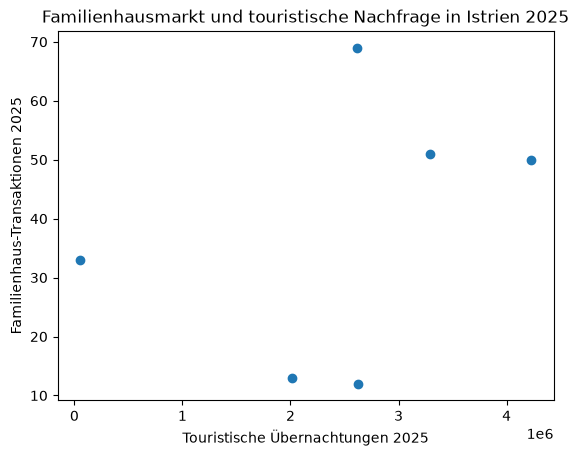

In [100]:
#Zusammenhang zwischen Familienhaus Transaktionen und touristischen Übernachtungen darstellen

plt.Figure(figsize=(8,5))

plt.scatter(
    df_house_tourism_comparison["Tourist nights"],
    df_house_tourism_comparison["2025._Transaktionen"]
)

plt.xlabel("Touristische Übernachtungen 2025")
plt.ylabel("Familienhaus-Transaktionen 2025")
plt.title(
    "Familienhausmarkt und touristische Nachfrage in Istrien 2025"
)

plt.show()

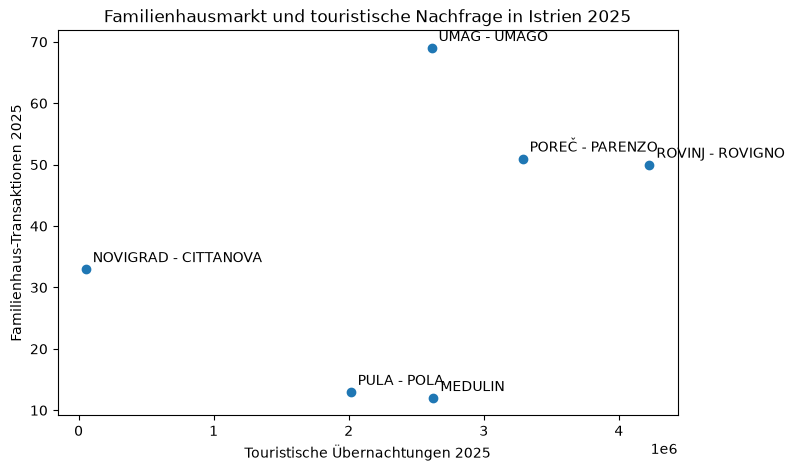

In [101]:
# Standorte in Scatterplot beschriften 
plt.figure(figsize=(8,5))

plt.scatter(
    df_house_tourism_comparison["Tourist nights"],
    df_house_tourism_comparison["2025._Transaktionen"]
)

for _,row in df_house_tourism_comparison.iterrows():
    plt.annotate(
        row["Naziv JLS-a"],
        (row["Tourist nights"], row["2025._Transaktionen"]),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("Touristische Übernachtungen 2025")
plt.ylabel("Familienhaus-Transaktionen 2025")
plt.title(
    "Familienhausmarkt und touristische Nachfrage in Istrien 2025"
)

plt.show()

# Interpretation 
Die Gegenüberstellung zeigt deutliche Unterschiede zwischen den untersuchten Standorten
Umag weist 2025 mit 69 veröffentlichten Familienhaus Transaktionen die höhste Marktaktivität auf.
Rovinj und Porec verbinden ebenfalls eine vergleichsweise hohe Zahl an Familienhaus Transaktionen mit einer hohen touristischen Nachfrage
Pula und Medulin verzeichnen dagegen trotz hoher touristischer Übernachtungszahlen deutlich weniger veröffentlichten Familienhaus Transaktionen. Die Ergebnisse zeigen. das eine hohe touristische Nachfrage nicht automatisch mit einer hohen Aktivität auf dem Familienhausmarkt verbunden ist. Die Standorte weisen unterschiedliche Kombinationen aus touristischer Nachfrage und Immobilienmarktaktivität auf.

In [102]:
# Korrelation zwischen Familienhaus Transaktionen und touristischen Übernachtungen berechnen

correlation_house_tourism = (
    df_house_tourism_comparison[
        ["2025._Transaktionen", "Tourist nights"]
    ]
    .corr()
)

correlation_house_tourism

,2025._Transaktionen,Tourist nights
2025._Transaktionen,1.000000,0.347095
Tourist nights,0.347095,1.000000


# Interpretation der Korrelation
Die Korrelation zwischen den touristischen Übernachtungen und den veröffentlichten Familienhaus Transaktionen beträgt rund 0,35.
Damit zeigt sich für die 6 untersuchten Standorte ein schwach bis moderat positiver linearer Zusammenhang. Standorte mit einer höhren touristischen Nachfragen weisen tendeziell auch eine höhere Aktivität auf dem Familienhausmarkt auf, der Zusammenhang ist jedoch nicht stark. Aufgrund der geringen Anzahl von 6 vergleichbaren Standorten wird die Korrelation ausschlißlich deskriptiv interpretiert.
Aus dem Ergebnis lässt sich kein kausaler Zusammenhang zwischen touristischen Nachfragen und Immobilienmarktaktivität ableiten.

# Zusammenführung der Analyseergebnisse
Die Analyse zeigt, dass sich die Immobilienmärkte der untersuchten Standorten in Istrien deutlich unterscheiden.
Dabei ergeben sich unterschiedliche Kombinationen aus Preisiveau, Marktaktivität und touristische Nachfrage.
Für Wohnungen und Apartments zeigen die Ergebnisse Unterschiede sowhol bei den medianen Preisen pro m² als auch bei der Anzahl der 
veröffentlichten Transaktionen.
Die Analyse des Zusammenhangs zwischen Preisniveau und Marktaktivität zeigt dabei nur einen begrenzten linearen Zusammenhang.
Auch der Familienhausmarkt weist deutlich regionale Unterschiede auf. Unter den Standorten, die mit den Tourismusdaten für 2025 verglichen werden konnten, verzeichnet Umag die höchste Zahl veröffentlichter Familienhaus Transaktionen. Rovinj und Porec verbinden ebenfalls eine vergleichsweise hohe Marktaktivität mit einer hohen touristischen Nachfragen.
Pula und Medulin weisen dagegen hohe touristische Übernachtungszahlen, aber vergleichsweise wenige veröffentlichte Familienhaus Transaktionen auf.
Insgesamt zeigen die Ergebnisse, das kein einzelner Indikator ausreicht, um die Standorte zu beuerteilen. Für die Beantwortung der Business Frage sollten daher Preisniveau, Marktaktivität und toursitische Nachfrage gemeinsam betrachtet werden.

# Handlungsempfehlungen 

Auf Basis der Analyse lasen sich für die weitere Betrachtung des istrischen Immobilienmarktes folgende Handlungsempfehlungen ableiten:

* Umag, Porec und Rovinj vertift beobachten
Diese Standorte zeigen 2025 eine interessante Kombination aus Immobilienmarktaktivität und touristische Nachfrage und eignen sich daher besonders für eine weiterführende Marktbeobachtung.

* Unterschiedliche Immobilientypen getrennt betrachten
Die Ergebnisse für Wohnungen und Apartments unterscheiden sich teilweise vom Familienhausmarkt.
Für potenzielle Käufer sollte daher zwischen den verschiedenen Immobilientypen differenziert werden.

* Touristische Nachfrage als ergänzenden Marktindikator nutzten
Hohe Übernachtungszahlen können auf die touristische Bedeutung eines Standortes hinweisen.
Die Analyse zeigt jedoch, dass touristische Nachfrage allein nicht ausreicht, um die Aktivität des Immobilienmarktes zu erklären.

* Weitere Daten für konkrete Kaufentscheidungen einbeziehen
Für eine detalierte Bewertung einzelner Standorte sollten zukunftig zusätzliche Faktoren wie Objektzustand, genaue Lage, Kaufnebenkosten,
Vermitungsmöglichkeiten und weitere lokale Marktinformationen berüksichtigt werden.

Für ein mögliches Geschäftsmodell zur Unterstüzung deutscher Immobilieninteressenten können die Ergebnisse als erste datenbasierte 
Grundlage dienen, um relevante Standorte zu identifizieren und die weitere Marktbeobachtung gezielter auszurichten.

# Limitationen der Analyse

Bei der Interpretation der Egebnisse sind einige Einschränkungen der verwendeten Daten zu berücksichtigen:

* Nicht veröffentlichte Immobilienwerte
In der offiziellen Immobilienmarktdaten werden Werte bei weniger als 10 Transaktionen teilweise aus Datenschutzgründen nicht veröffentlicht. Diese Werte wurden in der Analyse als fehlende Werte behandelt. Dadurch können insbesondere kleinere Städte und Gemeinden nicht vollständig miteinander verglichen werden.

* Begrenzte Vergleichbarkeit mit den Tourismusdaten
Für die gemeinsame Analyse von Familienhausmarkt und touristischer Nachfrage standen für 2025 sechs direkt vergleichbare Standorte zur Verfügung. Die Ergebnisse dieses Vergleichs sind daher deskriptiv zu verstehen und können nicht ohne Weiteres auf alle Standorte in Istrien übertragen werden.

* Touristische Nachfrage entspricht nicht der Immobiliennachfrage
Eine hohe Zahl touristischer Übernachtungen bedeuten nicht automatisch eine hohe Nachfrage nach Immobilien.
Die Tourismusdaten werden deshalb ausschließlich als ergänzender Indikator für die touristische Bedeutung eines Standortes verwendet.

* Weitere Einflussfaktoren sind nicht enthalten
Faktoren wie Mikrolage, Objektzustand,Grundstückgröße, Kaufnebenkosten, Vermitungspotenzial oder rechtliche Rahmenbedingungen wurden in dieser Analyse nicht berücksichtigt.

Die Ergebnisse stellen daher eine erste datenbasierte Marktübersicht dar und dienen als Grundlage für eine weitereführende Analyse des Immobilienmarktes in Istrien.